**Support Vector Machine (SVM)** is a supervised machine learning algorithm primarily used for classification, though it can also handle regression tasks. Its core objective is to find the optimal decision boundary—called a **hyperplane**—that separates different classes of data points with the maximum possible margin.

---

## Key Terminology

* **Hyperplane:** The decision boundary separating different classes. In 2D space, it's a straight line; in 3D, it's a plane; in higher dimensions, it's an $n$-dimensional hyperplane.
* **Support Vectors:** The data points closest to the hyperplane. These critical points directly define the position, orientation, and margin of the boundary.
* **Margin:** The distance between the decision boundary (hyperplane) and the nearest data point from any class. SVM maximizes this distance to generalize well to unseen data.

---

## Core Concepts

### 1. Hard vs. Soft Margin

* **Hard Margin:** Assumes data is strictly linearly separable with zero misclassifications allowed. Highly sensitive to outliers.
* **Soft Margin:** Uses a slack parameter ($C$) to allow a controlled amount of misclassification, making the model robust against noisy data.

### 2. The Kernel Trick

When data cannot be separated by a straight line in lower dimensions, SVM uses a **kernel function** to map the feature space into a higher-dimensional space where linear separation becomes possible.

| Kernel Function | Typical Use Case |
| --- | --- |
| **Linear** | Text classification, large sparse datasets |
| **Polynomial** | Image processing, feature interactions |
| **Radial Basis Function (RBF)** | Default choice; complex, non-linear datasets |
| **Sigmoid** | Neural network approximations |

---

## Strengths & Limitations

* **Pros:** Effective in high-dimensional spaces, memory efficient (uses only support vectors), versatile through different kernel functions.
* **Cons:** Slow on large datasets, sensitive to noise/outliers, requires careful feature scaling (e.g., Standardization).

In [1]:
# Cell 1: Import Libraries
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

### Explanation

This section imports the libraries needed for plotting, synthetic data generation, scaling, and SVM evaluation.


In [2]:
# Cell 2: Generate Synthetic Dataset
# Generate concentric circles to demonstrate non-linear SVM performance
X, y = make_circles(n_samples=500, noise=0.1, factor=0.3, random_state=42)

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 400 samples
Testing set size: 100 samples


### Explanation

A synthetic dataset with concentric circles is created to illustrate that some classification problems are not linearly separable and require a non-linear kernel.


In [3]:
# Cell 3: Feature Scaling
# Feature scaling is crucial for SVM to prevent features with larger scales from dominating
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Explanation

The feature values are standardized because SVM performance is sensitive to the scale of the input features.


In [4]:
# Cell 4: Train Support Vector Classifier
# We use the Radial Basis Function (RBF) kernel for non-linear decision boundaries
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_model.fit(X_train_scaled, y_train)

print(f"Number of Support Vectors: {len(svm_model.support_vectors_)}")
print(
    f"Support Vectors per Class: {svm_model.n_support_}"
)  # [Class 0, Class 1]

Number of Support Vectors: 31
Support Vectors per Class: [17 14]


### Explanation

This code trains an SVM with an RBF kernel, which allows the model to learn curved decision boundaries for non-linear data.


In [5]:
# Cell 5: Make Predictions and Evaluate
y_pred = svm_model.predict(X_test_scaled)

print("--- Model Accuracy ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred), "\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Model Accuracy ---
Accuracy: 100.00%

--- Confusion Matrix ---
[[43  0]
 [ 0 57]] 

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       1.00      1.00      1.00        57

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



### Explanation

The trained SVM predicts class labels for the test data and prints the accuracy, confusion matrix, and summary metrics.


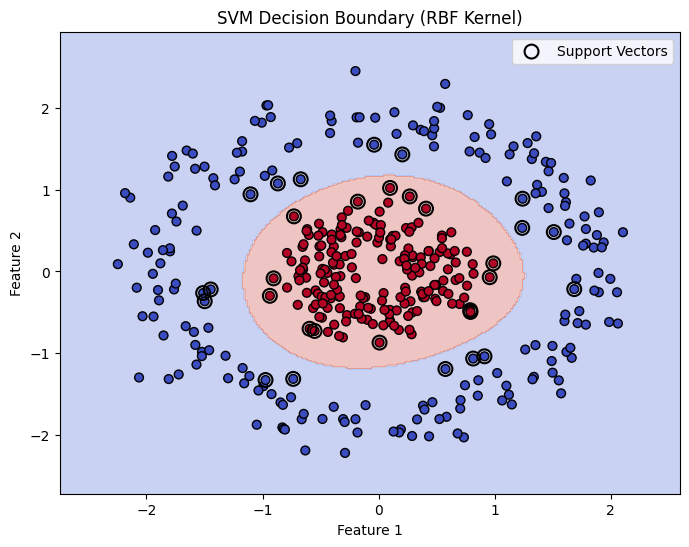

In [6]:
# Cell 6: Visualize Decision Boundary & Support Vectors
def plot_svm_decision_boundary(model, X, y):
  h = 0.02  # Mesh step size
  x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
  y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
  xx, yy = np.meshgrid(
      np.arange(x_min, x_max, h), np.arange(y_min, y_max, h)
  )

  # Predict over grid mesh
  Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)

  plt.figure(figsize=(8, 6))
  plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
  plt.scatter(
      X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors="k", s=40
  )

  # Highlight Support Vectors
  sv = model.support_vectors_
  plt.scatter(
      sv[:, 0],
      sv[:, 1],
      s=100,
      facecolors="none",
      edgecolors="k",
      linewidths=1.5,
      label="Support Vectors",
  )

  plt.title("SVM Decision Boundary (RBF Kernel)")
  plt.xlabel("Feature 1")
  plt.ylabel("Feature 2")
  plt.legend()
  plt.show()


plot_svm_decision_boundary(svm_model, X_train_scaled, y_train)

### Explanation

This final block draws the decision boundary and highlights the support vectors, showing how the model maximizes the margin between classes.
